<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_USGS_Earthquakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# USGS Earthquakes — 일별 집계 시계열 (전세계 vs 지역 비교: Korea / Japan / California)


> **학습목표 (전체(이 노트북))**
>
- USGS Earthquake API로 **가입/키 없이** 지진 이벤트 데이터를 수집한다.
- 전세계/지역(한반도·일본·캘리포니아)별 이벤트를 **일별 집계(count, mean/max magnitude)** 시계열로 변환한다.
- 지역별 시계열을 비교 시각화하고, log1p·STL·ACF로 구조를 진단한 뒤 베이스라인 예측을 구성한다.


### 🧭 수업 운영 포인트(‘패턴이 더 잘 보이게’ 튜닝)
- 전세계(GLOBAL)는 이벤트가 많아 그래프가 과밀해질 수 있어 **minmagnitude를 높이거나** 기간을 줄이는 것이 안정적입니다.
- 반대로 특정 지역(예: 한반도)은 이벤트가 적을 수 있어 **minmagnitude를 낮추거나(예: 3.0~4.0)** 기간을 늘려 패턴을 확보합니다.
- 아래 노트북은 **지역별 권장 minmagnitude**를 기본값으로 넣어 두었고, 학생들이 직접 바꿔 실험할 수 있게 했습니다.


## 0) 데이터 설명: USGS Earthquake API (가입/키 필요 없음)
- 엔드포인트: `https://earthquake.usgs.gov/fdsnws/event/1/query`
- 형식: `format=geojson`
- 기간: `starttime`, `endtime` (YYYY-MM-DD)
- 최소 규모: `minmagnitude`
- 공간 필터: 박스(min/max lat/lon) 또는 반경(maxradiuskm)
- 수업 안정성: 기간 1년 + 지역 필터 + 적절한 minmagnitude 조합 권장


## 1) 라이브러리/환경


In [1]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)


## 2) 지역 프리셋(박스 필터) + 권장 minmagnitude
아래는 교육용으로 ‘패턴이 잘 보이면서도 호출량이 과도하지 않게’ 잡은 박스 예시입니다.
- Korea 주변(한반도+근해): 이벤트가 상대적으로 적어 **min_mag를 낮게**
- Japan 주변: 활발한 지진대라 **min_mag 중간**
- California 주변: 이벤트가 많을 수 있어 **min_mag 중간~높게**

※ 박스는 대략값이며, 필요하면 더 정교하게 조정 가능합니다.


> **학습목표 (2) 지역 설정)**
>
- 전세계(GLOBAL)와 지역(BBOX) 수집의 차이를 이해한다.
- 지역별 minmagnitude를 조절해 ‘데이터가 너무 적거나 너무 많지 않게’ 수집량을 튜닝한다.
- 동일 기간에서 지역별 일별 count를 비교하는 방법을 익힌다.


In [2]:
START_DATE = '2025-03-07'
END_DATE   = '2026-03-07'

# 지역 프리셋
REGIONS = {
    'GLOBAL': {
        'bbox': None,
        'min_mag_default': 5.5,  # 전세계는 많으므로 높게 시작(원하면 4.5로 낮추세요)
        'note': '전세계(호출량 큼). 기간/최소규모를 조절하세요.'
    },
    'KOREA_BOX': {
        'bbox': {'minlatitude': 32.0, 'maxlatitude': 44.0, 'minlongitude': 122.0, 'maxlongitude': 133.0},
        'min_mag_default': 3.5,
        'note': '한반도 주변(이벤트 적을 수 있어 min_mag를 낮게).'
    },
    'JAPAN_BOX': {
        'bbox': {'minlatitude': 28.0, 'maxlatitude': 46.0, 'minlongitude': 128.0, 'maxlongitude': 148.0},
        'min_mag_default': 4.5,
        'note': '일본 주변(활발).'
    },
    'CALIFORNIA_BOX': {
        'bbox': {'minlatitude': 32.0, 'maxlatitude': 42.5, 'minlongitude': -125.0, 'maxlongitude': -114.0},
        'min_mag_default': 4.0,
        'note': '캘리포니아 주변(상대적으로 이벤트 많음).'
    }
}

# 실행 설정(하나 선택)
REGION_KEY = 'JAPAN_BOX'  # 'GLOBAL', 'KOREA_BOX', 'JAPAN_BOX', 'CALIFORNIA_BOX'
MIN_MAG = REGIONS[REGION_KEY]['min_mag_default']

REGION_KEY, MIN_MAG, REGIONS[REGION_KEY]['note']


('JAPAN_BOX', 4.5, '일본 주변(활발).')

### 🔎 출력 해석 포인트 (튜닝 포인트)
- GLOBAL은 이벤트가 많아 최소규모를 높이고(예: 5.5) 시작하는 것이 안정적입니다.
- KOREA는 이벤트가 적을 수 있어 최소규모를 낮추는 것이 좋습니다(예: 3.0~4.0).
- JAPAN/CALIFORNIA는 4.0~5.0 범위에서 적절히 조절하면 그래프가 보기 좋아집니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 전세계는 이벤트 수가 많으므로 minmagnitude를 (_____)게 시작하는 것이 안정적이다.
- Q2. 한반도 주변은 이벤트가 적을 수 있어 minmagnitude를 (_____)게 조절할 수 있다.
- Q3. REGION_KEY는 (_____)을 선택하는 스위치이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 높
- A2. 낮
- A3. 지역 프리셋

</details>


## 3) USGS 수집 함수(페이지네이션 포함)


In [3]:
BASE = 'https://earthquake.usgs.gov/fdsnws/event/1/query'

def fetch_usgs_events(start_date: str, end_date: str,
                      min_mag: float = 4.5,
                      bbox: dict | None = None,
                      limit: int = 20000,
                      sleep_sec: float = 0.25,
                      session: requests.Session | None = None) -> pd.DataFrame:
    """Fetch earthquake events from USGS within date range (GeoJSON).
    - Pagination via offset
    - Returns DataFrame with time(UTC), mag, lat/lon, depth
    """
    sess = session or requests.Session()
    offset = 1
    rows = []
    while True:
        params = {
            'format': 'geojson',
            'starttime': start_date,
            'endtime': end_date,
            'minmagnitude': min_mag,
            'orderby': 'time-asc',
            'limit': limit,
            'offset': offset,
        }
        if bbox is not None:
            params.update(bbox)
        r = sess.get(BASE, params=params, timeout=60)
        if r.status_code != 200:
            raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
        js = r.json()
        feats = js.get('features', [])
        if not feats:
            break
        for f in feats:
            p = f.get('properties', {})
            g = f.get('geometry', {})
            coords = g.get('coordinates', [None, None, None])
            rows.append({
                'time': pd.to_datetime(p.get('time', None), unit='ms', utc=True),
                'mag': p.get('mag', np.nan),
                'place': p.get('place', None),
                'lon': coords[0],
                'lat': coords[1],
                'depth_km': coords[2],
                'type': p.get('type', None),
                'id': f.get('id', None),
            })
        offset += len(feats)
        time.sleep(sleep_sec)
        if len(feats) < limit:
            break
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('time').reset_index(drop=True)
    return df

def events_to_daily(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregate event table to daily time series."""
    ev = events.copy()
    ev['date'] = ev['time'].dt.floor('D')  # UTC date
    daily = ev.groupby('date').agg(
        count=('id','count'),
        mag_mean=('mag','mean'),
        mag_max=('mag','max')
    ).sort_index()
    full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    daily = daily.reindex(full_idx)
    daily['count'] = daily['count'].fillna(0).astype(int)
    return daily


### 🔎 출력 해석 포인트 (이벤트→일별 집계)
- 이벤트는 불규칙 발생이므로, 분석을 위해 ‘일별 그리드’로 집계합니다.
- count는 0건 날짜를 포함해야 하므로 재색인 후 0으로 채웁니다.
- mag_mean/mag_max는 이벤트가 없는 날에는 NaN이 자연스럽습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 이벤트를 일별로 바꾸는 핵심 연산은 groupby(_____)이다.
- Q2. count 집계에서 0건 날짜는 (_____)로 채운다.
- Q3. 시간은 기본적으로 (_____) 기준(UTC)으로 제공된다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. date
- A2. 0
- A3. 협정세계시

</details>


## 4) 단일 지역 수집 실행(선택한 REGION_KEY)


In [4]:
sess = requests.Session()
bbox = REGIONS[REGION_KEY]['bbox']
events = fetch_usgs_events(START_DATE, END_DATE, min_mag=MIN_MAG, bbox=bbox, session=sess)
print('n_events =', len(events))
display(events.head())

daily = events_to_daily(events)
display(daily.head())
print(daily.isna().sum())


n_events = 568


,time,mag,place,lon,lat,depth_km,type,id
0,2025-03-08 07:12:17.150000+00:00,5.2,"41 km ENE of Noda, Japan",142.2891,40.2125,57.120,earthquake,us6000pxln
1,2025-03-08 18:54:04.724000+00:00,5.7,"63 km ENE of Tatsugō, Japan",130.1920,28.6865,24.000,earthquake,us6000pxnp
2,2025-03-08 18:57:13.620000+00:00,4.8,"69 km ENE of Tatsugō, Japan",130.2581,28.6867,24.816,earthquake,us6000pzdc
3,2025-03-08 23:42:55.012000+00:00,5.7,"74 km ENE of Tatsugō, Japan",130.2922,28.7303,26.000,earthquake,us6000pxpv
4,2025-03-09 00:09:19.572000+00:00,4.7,"57 km ENE of Tatsugō, Japan",130.1511,28.6359,36.284,earthquake,us6000pxq3


,count,mag_mean,mag_max
2025-03-08 00:00:00+00:00,4,5.350000,5.7
2025-03-09 00:00:00+00:00,5,4.860000,5.2
2025-03-10 00:00:00+00:00,2,4.650000,4.8
2025-03-11 00:00:00+00:00,3,4.866667,5.1
2025-03-12 00:00:00+00:00,1,4.500000,4.5


count         0
mag_mean    130
mag_max     130
dtype: int64


### 🔎 출력 해석 포인트 (수집량 점검)
- n_events가 너무 작으면(예: <50) minmagnitude를 낮추거나 기간을 늘립니다.
- n_events가 너무 크면(예: >50,000) minmagnitude를 높이거나 기간을 줄입니다.
- 수업에서는 ‘적당히 스파이크가 보이면서도’ 계산이 빠른 범위를 목표로 합니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 이벤트 수가 너무 적으면 minmagnitude를 (_____)다.
- Q2. 이벤트 수가 너무 많으면 minmagnitude를 (_____)다.
- Q3. 일별 count는 이벤트가 없는 날도 포함해야 하므로 날짜를 (_____)한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 내린
- A2. 올린
- A3. 재색인(reindex)

</details>


## 5) 지역 비교(3개 지역을 한 번에) — ‘패턴이 보이게’
학생 반응을 높이려면, 한 지역만 보는 것보다 **지역 비교**가 훨씬 효과적입니다.
- 아래는 동일 기간에서 Korea/Japan/California의 일별 count를 한 번에 수집·집계해 비교합니다.
- 데이터가 많아지면 느려질 수 있으니, 기간을 줄이거나 minmagnitude를 올리세요.


> **학습목표 (5) 지역 비교)**
>
- 동일 기간에서 여러 지역의 일별 count 시계열을 비교한다.
- 지역별 minmagnitude 튜닝이 ‘데이터 시각화 품질’에 미치는 영향을 이해한다.


,KOREA_BOX_count(m≥3.5),JAPAN_BOX_count(m≥4.5),CALIFORNIA_BOX_count(m≥4.0)
2025-03-08 00:00:00+00:00,NaN,4,NaN
2025-03-09 00:00:00+00:00,NaN,5,1.0
2025-03-10 00:00:00+00:00,NaN,2,0.0
2025-03-11 00:00:00+00:00,NaN,3,0.0
2025-03-12 00:00:00+00:00,NaN,1,0.0


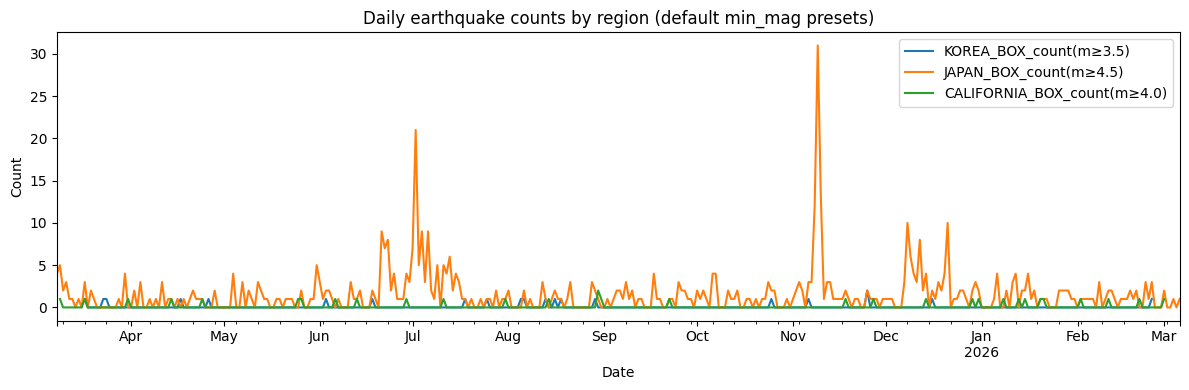

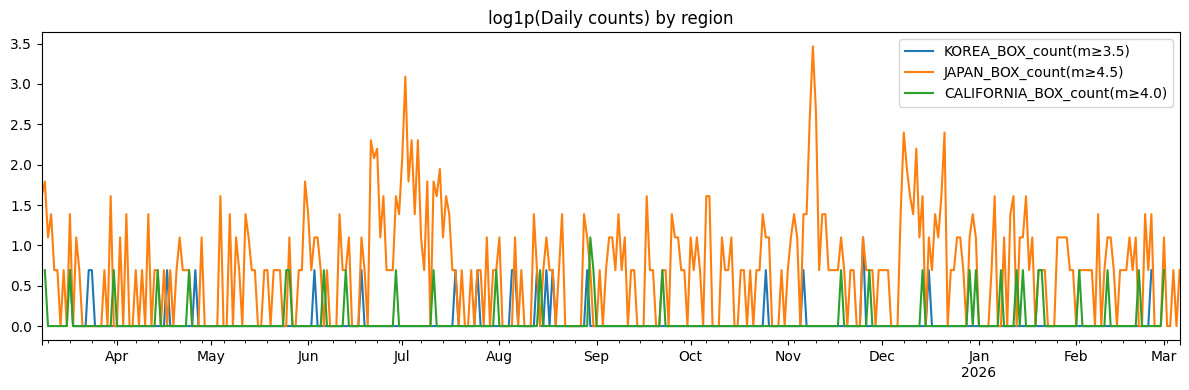

In [5]:
# 비교할 지역 3개 선택
COMPARE_KEYS = ['KOREA_BOX', 'JAPAN_BOX', 'CALIFORNIA_BOX']

sess = requests.Session()
daily_map = {}
for key in COMPARE_KEYS:
    bbox = REGIONS[key]['bbox']
    min_mag = REGIONS[key]['min_mag_default']
    ev = fetch_usgs_events(START_DATE, END_DATE, min_mag=min_mag, bbox=bbox, session=sess)
    d = events_to_daily(ev)
    # 컬럼명에 min_mag를 포함해 ‘조건’을 드러내기
    daily_map[key] = d['count'].rename(f"{key}_count(m≥{min_mag})")

df_cmp = pd.concat(daily_map.values(), axis=1)
display(df_cmp.head())

df_cmp.plot(title='Daily earthquake counts by region (default min_mag presets)')
plt.xlabel('Date'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

# 로그 스케일(스파이크 완화)
df_cmp_log = np.log1p(df_cmp)
df_cmp_log.plot(title='log1p(Daily counts) by region')
plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (지역 비교 해석)
- 지역별 지진대 특성(판 경계 등)에 따라 발생 빈도와 변동성이 달라집니다.
- minmagnitude를 낮추면 이벤트 수가 늘어나고, 변동성이 커질 수 있습니다.
- 로그 변환은 지역 간 스케일 차이를 비교하기 쉽게 해줍니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. minmagnitude를 낮추면 일반적으로 count는 (_____)한다.
- Q2. log1p는 스파이크를 (_____)해 비교를 쉽게 한다.
- Q3. 지역 비교는 데이터의 (_____) 차이를 직관적으로 보여준다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 증가
- A2. 완화
- A3. 공간적(spatial)

</details>


## 6) 진단(STL/ACF) — 한 지역 선택
지진 발생은 자연현상이라 ‘주간 계절성’이 약할 수 있습니다. 그래도 STL/ACF를 통해
1) 군집(cluster) 기간, 2) 잔차 스파이크, 3) 자기상관의 존재 여부를 연습할 수 있습니다.


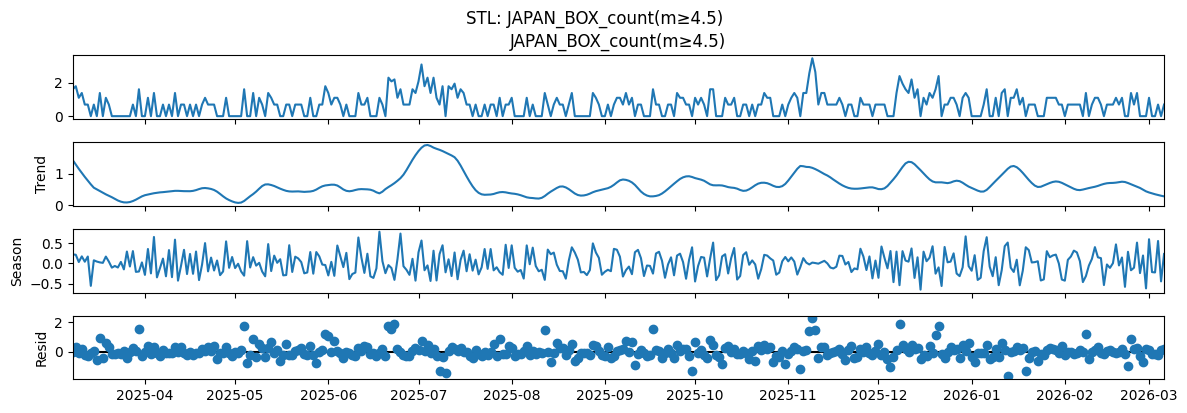

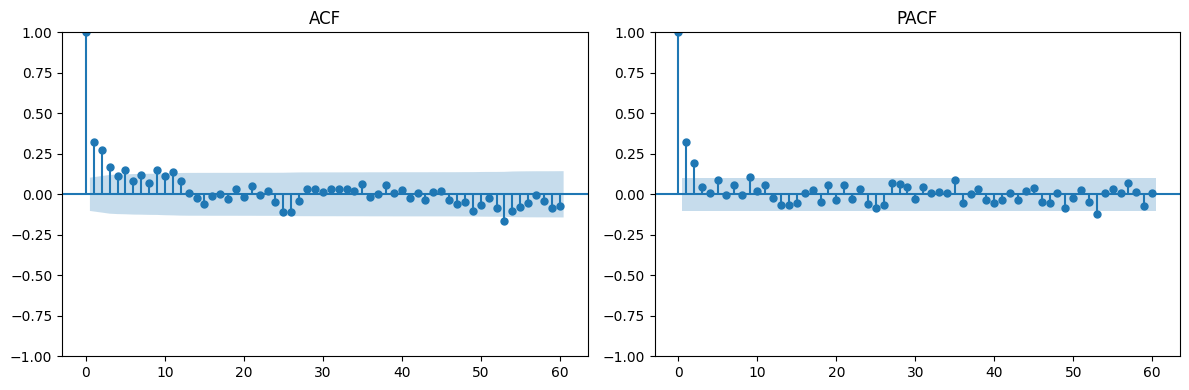

In [6]:
TARGET_COL = df_cmp_log.columns[1]  # 예: Japan 컬럼
y = df_cmp_log[TARGET_COL].dropna()

stl = STL(y, period=7, robust=True)
res = stl.fit()
res.plot(); plt.suptitle(f'STL: {TARGET_COL}', y=1.02); plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, lags=60, ax=ax[0]); ax[0].set_title('ACF')
plot_pacf(y, lags=60, ax=ax[1], method='ywm'); ax[1].set_title('PACF')
plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (진단 포인트)
- Residual 스파이크는 특정 기간의 지진 군집(여진 포함)을 시사할 수 있습니다.
- ACF가 천천히 감쇠하면 군집/레짐 구조가 남아있을 수 있습니다.
- 이 데이터는 ‘정확한 예측’보다 ‘집계·진단·변화 탐지’에 더 교육적 가치가 큽니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Residual 스파이크는 지진 (_____) 기간을 시사할 수 있다.
- Q2. ACF가 천천히 감쇠하면 자기상관 구조가 (_____) 남아있을 수 있다.
- Q3. 이벤트형 시계열은 예측보다 (_____) 탐지에 적합한 경우가 많다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 군집(cluster)
- A2. 오래
- A3. 변화점

</details>


## 7) 간단 베이스라인 예측: Seasonal Naïve(7일)


Seasonal Naive(h=7) | RMSE=0.6316, MAE=0.4739  (log1p count)


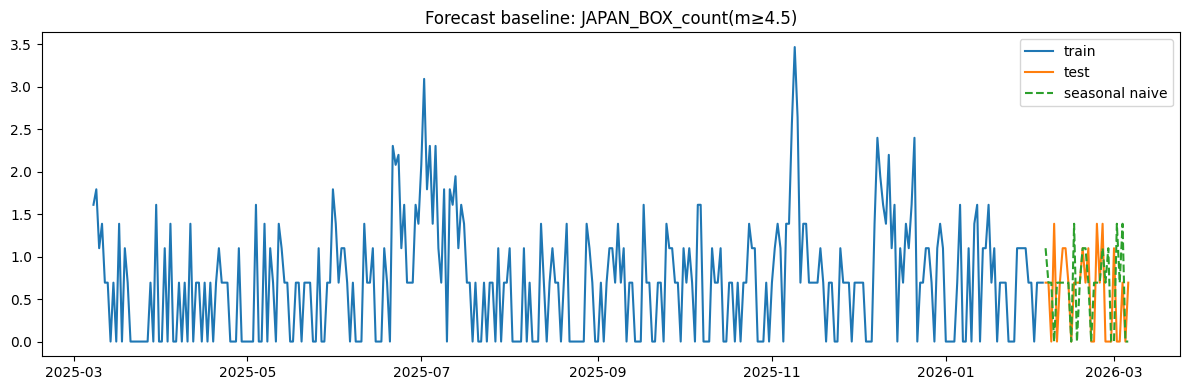

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 7
test_n = 30
y_train = y.iloc[:-test_n]
y_test  = y.iloc[-test_n:]

y_pred = y_test.copy()*np.nan
for t in y_test.index:
    t_lag = t - pd.Timedelta(days=h)
    if t_lag in y.index:
        y_pred.loc[t] = y.loc[t_lag]

rmse = math.sqrt(mean_squared_error(y_test.dropna(), y_pred.dropna()))
mae  = mean_absolute_error(y_test.dropna(), y_pred.dropna())
print(f'Seasonal Naive(h={h}) | RMSE={rmse:.4f}, MAE={mae:.4f}  (log1p count)')

plt.figure(figsize=(12,4))
plt.plot(y_train.index, y_train, label='train')
plt.plot(y_test.index, y_test, label='test')
plt.plot(y_pred.index, y_pred, label='seasonal naive', linestyle='--')
plt.title(f'Forecast baseline: {TARGET_COL}')
plt.legend(); plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (베이스라인 해석)
- Seasonal Naïve는 ‘지난주 같은 요일’ 값을 그대로 쓰는 기준선입니다.
- 지진은 주간 계절성이 약할 수 있으므로, 이 베이스라인은 ‘모형 비교 훈련용’으로 이해하는 것이 적절합니다.
- 확장 방향: 포아송/네거티브바이노미얼 회귀, 상태공간, 레짐전환, Hawkes(자기흥분) 프로세스 등.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Seasonal Naïve(h=7)는 ŷ_t = y_{t-(_____) }이다.
- Q2. 지진 데이터는 계절성보다 (_____) 효과가 더 중요할 수 있다.
- Q3. 카운트 모델 확장으로는 포아송 또는 (_____) 분포 기반 모델을 고려할 수 있다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 7
- A2. 군집/여진
- A3. 네거티브바이노미얼

</details>


## ✅ 마무리 (요약 3줄)
1) USGS Earthquake API는 **가입/키 없이** 지진 이벤트 데이터를 제공하며, 이벤트→일별 집계로 시계열을 만들 수 있습니다.
2) ‘패턴이 보이게’ 하려면 **지역 필터 + minmagnitude 튜닝**이 핵심입니다(너무 많거나 너무 적지 않게).
3) 지진 카운트는 예측보다 **군집/변화 탐지** 학습에 특히 유용하며, log1p·STL·ACF로 구조를 빠르게 진단할 수 있습니다.

### ➡️ 다음 확장(선택)
- (A) 특정 큰 지진 이후 기간을 잘라 ‘여진 군집’을 집중 분석
- (B) count를 포아송 회귀로 모델링(외생변수: 판 경계 거리, 깊이 등)
- (C) 자기흥분(Hawkes) 프로세스로 이벤트 자체를 모델링(고급)
